
# Comparing Image Shapley-Value Explainers
### Shapiq Vision &nbsp;·&nbsp; ProxySHAP &nbsp;·&nbsp; Captum KernelSHAP



In [ ]:
# shapiq.vision is not on PyPI yet - install shapiq from the project fork
!pip install "git+https://github.com/S2k-1/shapiq.git@feature/protocols" captum --quiet


## 1 · Setup

In [2]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from PIL import Image
from torchvision import models, transforms
from skimage.segmentation import slic, mark_boundaries

import shapiq
from captum.attr import KernelShap

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda



## 2 · Config

- `IMAGE_PATH` — the image to explain (drop in any other image and re-run).
- `N_SEGMENTS` — target number of superpixels (players in the game).
- `BUDGET` — number of value-function evaluations each method is allowed. Keeping
  this identical across methods is what makes the comparison fair.


In [3]:
IMAGE_PATH = "guitardog.png"
N_SEGMENTS = 50
BUDGET = 1024          # model calls allowed per method

MAX_ORDER = 1          # Shapley order (1 = per-player importance, no interactions)
INDEX = "SV"           # Shapley value index
ADJUSTMENT = "msr"     # ProxySHAP residual-adjustment method


## 3 · Load the image and the model

We use a pretrained ResNet-18 (ImageNet). The dog-with-a-guitar photo is a nice
stress test: it contains a salient face, a guitar, a hat, and clothing, so it's
interesting to see which regions the explainers credit for the top prediction.


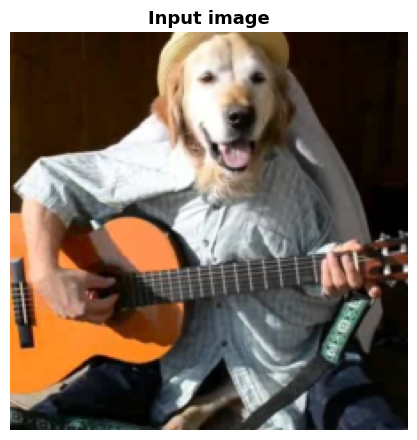

Top-5 predictions:
  acoustic guitar                0.402
  stage                          0.216
  electric guitar                0.157
  harmonica                      0.046
  golden retriever               0.024
Explaining class: 'acoustic guitar'


In [4]:
pil_image = Image.open(IMAGE_PATH).convert("RGB")

resize_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])
to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resized_image = resize_crop(pil_image)
image_np = np.array(resized_image)                       # (224, 224, 3), for plotting/masking
tensor_image = to_tensor_norm(resized_image).unsqueeze(0).to(device)  # (1, 3, 224, 224)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval().to(device)
categories = weights.meta["categories"]

with torch.no_grad():
    probs_full = torch.softmax(model(tensor_image), dim=1)[0]
top5 = torch.topk(probs_full, 5)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(image_np)
ax.axis("off")
ax.set_title("Input image", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top-5 predictions:")
for p, i in zip(top5.values, top5.indices):
    print(f"  {categories[i]:<30s} {p.item():.3f}")

target_class = int(top5.indices[0].item())
print(f"Explaining class: '{categories[target_class]}'")


## 4 · Define the players: superpixel regions

Each superpixel is one "player" in the coalition game.


Requested 50 superpixels, got 39 players


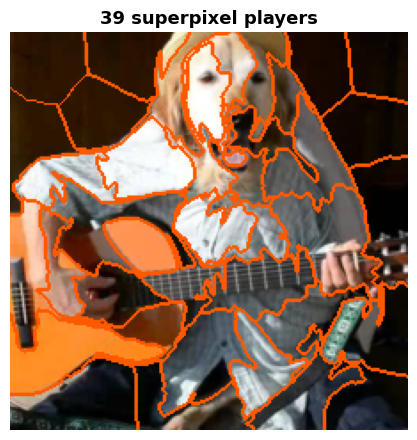

In [5]:
segments = slic(image_np, n_segments=N_SEGMENTS, compactness=12, sigma=1, start_label=0)
n_players = int(segments.max()) + 1
print(f"Requested {N_SEGMENTS} superpixels, got {n_players} players")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(mark_boundaries(image_np, segments, color=(1, 0.35, 0)))
ax.set_title(f"{n_players} superpixel players", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5 · Average baseline

In [6]:
spatial_dims = tuple(range(tensor_image.ndim - 2, tensor_image.ndim))  # Gets last two dims (H, W)
mean_vals = tensor_image.mean(dim=spatial_dims, keepdim=True)
baseline = mean_vals.expand_as(tensor_image)

seg_t = torch.from_numpy(segments).to(device)  # (H, W) long tensor, same superpixel ids as `segments`


## 6 · Method A — Shapiq Vision


In [7]:
# Shapiq Vision plays the exact same game as Methods B and C:
#  - players: the same SLIC `segments` (via CustomPlayerStrategy)
#  - removal: mean-color baseline (MeanColorMasking; Normalize is affine, so the
#    channel mean in [0, 1] pixel space equals the mean of the normalized tensor)
#  - payoff:  logit of `target_class`
#
#   vals_vision  -> np.ndarray of shape (n_players,), the per-superpixel Shapley values
#   time_vision  -> float, wall-clock seconds
#   calls_vision -> int, number of model calls used
from shapiq.vision import CNNArchitecture, ImageExplainer, MeanColorMasking
from shapiq.vision.players import CustomPlayerStrategy

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


class CountedModel(torch.nn.Module):
    """shapiq feeds [0, 1] images, so normalization lives inside the model.
    Counting forward-pass rows keeps budget usage comparable across methods."""

    def __init__(self, model):
        super().__init__()
        self.model = model
        self.n_calls = 0

    def forward(self, x):
        self.n_calls += x.shape[0]
        return self.model(normalize(x))


counted_model = CountedModel(model).eval().to(device)

t0 = time.time()

architecture = CNNArchitecture(
    model=counted_model,
    masking_strategy=MeanColorMasking(),
    player_strategy=CustomPlayerStrategy(segments),
)
explainer = ImageExplainer(
    model=architecture,
    data=image_np,
    class_index=target_class,
    index=INDEX,
    max_order=MAX_ORDER,
    random_state=SEED,
)
iv_vision = explainer.explain(budget=BUDGET)

time_vision = time.time() - t0
calls_vision = counted_model.n_calls
vals_vision = iv_vision.get_n_order_values(1)
print(f"Method A - done in {time_vision:.1f}s, {calls_vision} model calls")


Method A - done in 0.4s, 1025 model calls



## 7 · Method B — ProxySHAP

In [8]:
def value_function(coalitions: np.ndarray) -> np.ndarray:
    """coalitions: (n_players,) or (n_coalitions, n_players) bool array.
    Returns P(target_class) for each coalition. Increments the global call
    counter so each method's budget usage can be reported later."""
    global n_calls
    n_calls += coalitions.shape[0]
    outputs = []
    for coalition in coalitions:
        active_ids = np.where(coalition)[0]
        if len(active_ids) == 0:
            mask = torch.zeros_like(seg_t, dtype=torch.bool)
        else:
            active_t = torch.as_tensor(active_ids, device=device)
            mask = torch.isin(seg_t, active_t)
        masked = torch.where(mask, tensor_image[0], baseline[0]).unsqueeze(0)
        with torch.no_grad():
            out = model(masked)[:, target_class]
        outputs.append(out.item())
    return np.array(outputs)

In [9]:
from shapiq.approximator import ProxySHAP

n_calls = 0
t0 = time.time()

approximator = ProxySHAP(
    n=n_players,
    max_order=MAX_ORDER,
    index=INDEX,
    adjustment=ADJUSTMENT,
    random_state=SEED,
)
iv_proxy = approximator.approximate(budget=BUDGET, game=value_function)

time_proxy = time.time() - t0
calls_proxy = n_calls
vals_proxy = np.array([iv_proxy[(i,)] for i in range(n_players)])
print(f"Method B - done in {time_proxy:.1f}s, {calls_proxy} model calls")

Method B - done in 3.5s, 1024 model calls



## 8 · Method C — Captum `KernelShap`


In [10]:
from captum.attr import KernelShap

n_calls = 0
t0 = time.time()

feature_mask = seg_t.long().unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)

def _counted_model(x):
    global n_calls
    n_calls += x.shape[0]
    return model(x)

ks = KernelShap(_counted_model)

attributions = ks.attribute(
    inputs=tensor_image,
    baselines=baseline,
    target=target_class,
    feature_mask=feature_mask,
    n_samples=BUDGET,
)

time_captum = time.time() - t0
calls_captum = n_calls
attr_np = attributions[0, 0].detach().cpu().numpy()
vals_captum = np.array([attr_np[segments == i].mean() for i in range(n_players)])
print(f"Method C - done in {time_captum:.1f}s, {calls_captum} model calls")

Method C - done in 4.0s, 1024 model calls


## 9 · Runtime & budget summary

In [11]:
import pandas as pd

results = {}
if "vals_vision" in dir():
    results["A - Shapiq Vision"] = (vals_vision, time_vision, calls_vision)
results["B - ProxySHAP"] = (vals_proxy, time_proxy, calls_proxy)
results["C - Captum KernelSHAP"] = (vals_captum, time_captum, calls_captum)

summary = pd.DataFrame({
    "Method": list(results.keys()),
    "Wall time (s)": [v[1] for v in results.values()],
    "Model calls": [v[2] for v in results.values()],
})
summary["Time / call (ms)"] = 1000 * summary["Wall time (s)"] / summary["Model calls"]
summary.round({"Wall time (s)": 2, "Time / call (ms)": 3}).set_index("Method")


,Wall time (s),Model calls,Time / call (ms)
Method,,,
A - Shapiq Vision,0.37,1025,0.363
B - ProxySHAP,3.54,1024,3.454
C - Captum KernelSHAP,4.00,1024,3.903



## 10 · Visual comparison

Each heatmap shows per-superpixel Shapley values overlaid on the original image


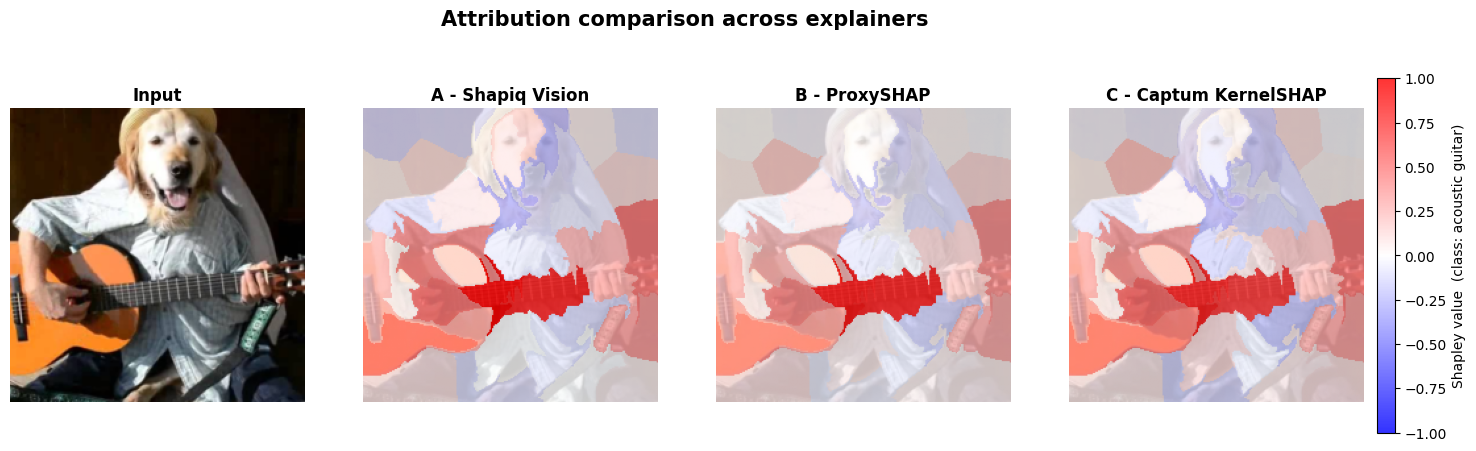

In [12]:
def attribution_map(values, segments):
    out = np.zeros(segments.shape, dtype=np.float32)
    for i, v in enumerate(values):
        out[segments == i] = v
    return out

names = list(results.keys())
maps = [attribution_map(results[name][0], segments) for name in names]
vmax = max(np.abs(m).max() for m in maps)
maps = [m / vmax for m in maps]
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, axes = plt.subplots(1, len(names) + 1, figsize=(4.5 * (len(names) + 1), 4.6))
axes[0].imshow(image_np)
axes[0].set_title("Input", fontsize=12, fontweight="bold")
axes[0].axis("off")

for ax, m, title in zip(axes[1:], maps, names):
    ax.imshow(image_np)
    im = ax.imshow(m, cmap="bwr", norm=norm, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
cbar.set_label(f"Shapley value  (class: {categories[target_class]})", fontsize=10)
fig.suptitle("Attribution comparison across explainers", fontsize=15, fontweight="bold", y=1.03)
plt.show()


## 11 · Top contributing superpixels per method

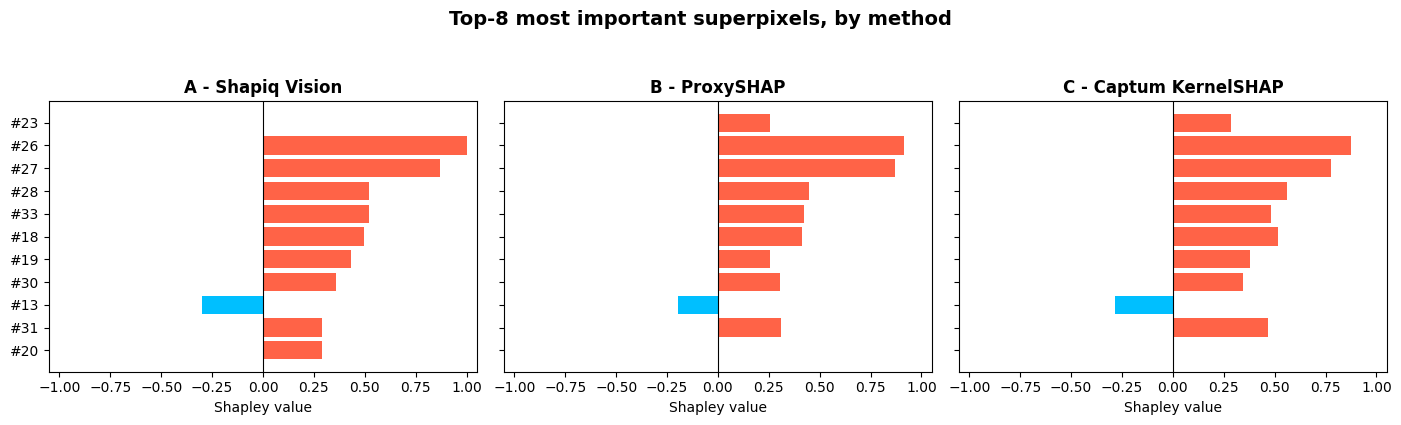

In [13]:
vec = {name: results[name][0] for name in results}
names = list(vec.keys())

vmax = max(np.abs(v).max() for v in vec.values())   # shared scale across all methods

fig, axes = plt.subplots(1, len(names), figsize=(4.7 * len(names), 4), sharey=True)
if len(names) == 1:
    axes = [axes]
for ax, name in zip(axes, names):
    v = vec[name] / vmax
    order = np.argsort(np.abs(v))[::-1][:10]
    colors = ["tomato" if v[i] >= 0 else "deepskyblue" for i in order]
    ax.barh([f"#{i}" for i in order][::-1], v[order][::-1], color=colors[::-1])
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel("Shapley value")
fig.suptitle("Top-8 most important superpixels, by method", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()